In [1]:

# ============================================================
# CONFIGURATION
# ============================================================

class CFG:

    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"


    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda"


In [2]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
df.columns = ["id", "text_label", "image_label", "final_label"]

def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

df = df[df.apply(is_valid, axis=1)]
df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

# Track failed samples for debugging
failed_samples = []

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

if empty_text_count > 0:
    print("IDs with empty text:")
    empty_ids = df[df["text"] == ""]["id"].tolist()
    for idx in empty_ids[:10]:  # Show first 10
        print(f"  - {idx}")
    if len(empty_ids) > 10:
        print(f"  ... and {len(empty_ids) - 10} more")
    print()

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()


Dataset size after filtering: 4511

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [3]:

# ============================================================
# IMPORTS & HYPERPARAMETERS
# ============================================================
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaModel
from torchvision import transforms
from torchvision.models import vit_b_16
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from PIL import Image
import numpy as np, os, copy, warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 2e-5
MAX_LEN = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Device: {DEVICE}')
print(f'Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE}')


c:\Users\Residensi ADW\anaconda3\envs\env_gpu_pytorch_erl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Batch: 32 | Epochs: 20 | LR: 2e-05


In [4]:

# ============================================================
# TRAIN / VAL / TEST SPLIT  (80% / 10% / 10%)
# ============================================================
train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df['label'],
    random_state=RANDOM_SEED, shuffle=True
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'],
    random_state=RANDOM_SEED, shuffle=True
)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f"\nTrain label dist:\n{train_df['label'].value_counts().sort_index()}")
print(f"\nVal   label dist:\n{val_df['label'].value_counts().sort_index()}")
print(f"\nTest  label dist:\n{test_df['label'].value_counts().sort_index()}")


Train: 3608 | Val: 451 | Test: 452

Train label dist:
label
0    1086
1     376
2    2146
Name: count, dtype: int64

Val   label dist:
label
0    136
1     47
2    268
Name: count, dtype: int64

Test  label dist:
label
0    136
1     47
2    269
Name: count, dtype: int64


In [5]:

# ============================================================
# CUSTOM DATASET & TOKENIZER / TRANSFORMS
# ============================================================

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class MultimodalDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = str(row['text'])
        encoding = tokenizer(
            text,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        img_path = row['image_path']
        try:
            img = Image.open(img_path).convert('RGB')
            img = img_transform(img)
        except Exception:
            img = torch.zeros(3, 224, 224)

        label = torch.tensor(row['label'], dtype=torch.long)

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'image': img,
            'label': label
        }


train_dataset = MultimodalDataset(train_df)
val_dataset   = MultimodalDataset(val_df)
test_dataset  = MultimodalDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')


Train batches: 113 | Val batches: 15 | Test batches: 15


In [6]:

# ============================================================
# CO-ATTENTION FUSION MODEL
# Architecture: Bidirectional Affinity Matrix Co-Attention
#
# FUSION MECHANISM (Co-Attention):
#   1. Text  -> RoBERTa last_hidden_state      (B, T, 768)
#   2. Image -> ViT-B/16 patch tokens           (B, P, 768)
#   3. Project both to shared space d=512 via Linear layers
#   4. Affinity Matrix: C = tanh(X_t @ W_b @ X_v^T)  (B, T, P)
#   5. Bidirectional Co-Attention:
#      - Text attends over Image:  H_t_co = softmax(C) @ X_v
#      - Image attends over Text:  H_v_co = softmax(C^T) @ X_t
#   6. Mean pool both -> concat -> MLP classifier (3 classes)
# ============================================================

class CoAttentionFusionModel(nn.Module):
    def __init__(self, num_classes=3, joint_dim=512, dropout=0.3):
        super().__init__()

        # --- Text Encoder: RoBERTa-base (sequence output) ---
        self.text_encoder = RobertaModel.from_pretrained('roberta-base')
        self.text_hidden = self.text_encoder.config.hidden_size  # 768
        self._freeze_roberta_layers(num_unfreeze=4)

        # --- Image Encoder: ViT-B/16 (patch sequence) ---
        vit = vit_b_16(pretrained=True)
        self.vit_conv_proj = vit.conv_proj
        self.vit_class_token = vit.class_token
        self.vit_encoder = vit.encoder
        self.image_hidden = vit.hidden_dim  # 768
        self._freeze_vit_blocks(num_unfreeze=4)

        # --- Projection to joint space ---
        self.text_proj = nn.Linear(self.text_hidden, joint_dim)
        self.image_proj = nn.Linear(self.image_hidden, joint_dim)

        # --- Co-Attention: bilinear affinity weight ---
        self.W_b = nn.Parameter(torch.randn(joint_dim, joint_dim) * 0.02)

        # --- Classifier ---
        hidden_dim = 256
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(joint_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    # ------------------------------------------------
    # FREEZING HELPERS
    # ------------------------------------------------
    def _freeze_roberta_layers(self, num_unfreeze=4):
        for param in self.text_encoder.embeddings.parameters():
            param.requires_grad = False
        total = self.text_encoder.config.num_hidden_layers  # 12
        for i, layer in enumerate(self.text_encoder.encoder.layer):
            if i < total - num_unfreeze:
                for param in layer.parameters():
                    param.requires_grad = False

    def _freeze_vit_blocks(self, num_unfreeze=4):
        for param in self.vit_conv_proj.parameters():
            param.requires_grad = False
        total = len(self.vit_encoder.layers)  # 12
        for i, block in enumerate(self.vit_encoder.layers):
            if i < total - num_unfreeze:
                for param in block.parameters():
                    param.requires_grad = False

    # ------------------------------------------------
    # IMAGE PATCH ENCODING
    # ------------------------------------------------
    def encode_image_patches(self, x):
        # x: (B, 3, 224, 224)
        n = x.shape[0]
        x = self.vit_conv_proj(x)              # (B, 768, 14, 14)
        x = x.flatten(2).permute(0, 2, 1)      # (B, 196, 768)
        cls = self.vit_class_token.expand(n, -1, -1)  # (B, 1, 768)
        x = torch.cat([cls, x], dim=1)         # (B, 197, 768)
        x = self.vit_encoder(x)                # (B, 197, 768)  incl. pos_embed
        return x[:, 1:, :]                     # patch tokens only (B, 196, 768)

    # ------------------------------------------------
    # FORWARD
    # ------------------------------------------------
    def forward(self, input_ids, attention_mask, image):
        B = input_ids.shape[0]

        # 1. Unimodal encodings
        text_out = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        )
        X_t = text_out.last_hidden_state   # (B, T, 768)
        X_v = self.encode_image_patches(image)  # (B, P, 768)

        # 2. Project to joint space d=512
        X_t_proj = self.text_proj(X_t)     # (B, T, d)
        X_v_proj = self.image_proj(X_v)    # (B, P, d)

        # 3. Affinity Matrix: C[i,j] = affinity(text_token_i, image_patch_j)
        #    C = tanh( X_t_proj @ W_b @ X_v_proj^T )  -- bilinear form
        X_t_w = X_t_proj @ self.W_b               # (B, T, d)
        C = torch.tanh(X_t_w @ X_v_proj.transpose(-2, -1))  # (B, T, P)

        # 4. Bidirectional Co-Attention
        #    Text attends over Image patches:
        A_t2v = torch.softmax(C, dim=-1)          # (B, T, P)
        H_t_co = A_t2v @ X_v_proj                 # (B, T, d)  text enriched with visual info

        #    Image attends over Text tokens:
        A_v2t = torch.softmax(C.transpose(-2, -1), dim=-1)  # (B, P, T)
        H_v_co = A_v2t @ X_t_proj                 # (B, P, d)  image enriched with textual info

        # 5. Pool co-attended sequences -> concat -> classify
        t_pooled = H_t_co.mean(dim=1)  # (B, d)
        v_pooled = H_v_co.mean(dim=1)  # (B, d)
        fused = torch.cat([t_pooled, v_pooled], dim=1)  # (B, 2d)
        logits = self.classifier(fused)                    # (B, 3)

        return logits


model = CoAttentionFusionModel(num_classes=3).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 15103.42it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 58,759,939 / 211,757,059  (27.7%)


In [7]:

# ============================================================
# OPTIMIZER, LOSS & SCHEDULER
# ============================================================
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


In [8]:

# ============================================================
# TRAINING & VALIDATION FUNCTIONS
# ============================================================

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='Training', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='Evaluating', leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, images)
        loss = criterion(logits, labels)

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1


In [9]:

# ============================================================
# TRAINING LOOP
# Saves best model checkpoint by validation loss
# ============================================================
best_val_loss = float('inf')
best_model_state = None
history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   [], 'val_f1': []}

print('=' * 70)
print(f'{"EPOCH":<8} {"TRAIN LOSS":<12} {"TRAIN ACC":<12} {"VAL LOSS":<12} {"VAL ACC":<12} {"VAL F1":<12}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    val_loss, val_acc, val_f1 = evaluate(
        model, val_loader, criterion, DEVICE
    )
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'{epoch:<8} {train_loss:<12.4f} {train_acc:<12.4f} '
          f'{val_loss:<12.4f} {val_acc:<12.4f} {val_f1:<12.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'  >>> Best model saved (val_loss = {best_val_loss:.4f})')

print('=' * 70)
print(f'Training complete. Best val_loss = {best_val_loss:.4f}')

torch.save(best_model_state, 'co_attention_best.pt')
print('Model saved to co_attention_best.pt')


EPOCH    TRAIN LOSS   TRAIN ACC    VAL LOSS     VAL ACC      VAL F1      


1        0.8553       0.6156       0.7321       0.6785       0.4400      
  >>> Best model saved (val_loss = 0.7321)


2        0.6762       0.7137       0.6712       0.7095       0.5540      
  >>> Best model saved (val_loss = 0.6712)


3        0.5569       0.7780       0.6702       0.7317       0.5722      
  >>> Best model saved (val_loss = 0.6702)


4        0.4530       0.8243       0.7467       0.7118       0.5703      


...

16       0.0268       0.9906       1.3710       0.7140       0.6354      


17       0.0259       0.9886       1.3919       0.7184       0.6364      


18       0.0239       0.9892       1.4075       0.7140       0.6265      


19       0.0199       0.9922       1.4069       0.7162       0.6389      


20       0.0243       0.9911       1.4100       0.7162       0.6400      
Training complete. Best val_loss = 0.6702
Model saved to co_attention_best.pt


In [10]:

# ============================================================
# TEST EVALUATION
# Load best checkpoint, evaluate on test set
# ============================================================
print('\n' + '=' * 70)
print('TEST SET EVALUATION')
print('=' * 70)

model.load_state_dict(best_model_state)
test_loss, test_acc, test_f1 = evaluate(
    model, test_loader, criterion, DEVICE
)

print(f'\n{"Test Loss:":<20s} {test_loss:.4f}')
print(f'{"Test Accuracy:":<20s} {test_acc:.4f}')
print(f'{"Test Macro F1:":<20s} {test_f1:.4f}')



TEST SET EVALUATION



Test Loss:           0.6660
Test Accuracy:       0.7301
Test Macro F1:       0.5907


In [11]:

# ============================================================
# DETAILED CLASSIFICATION REPORT
# ============================================================
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc='Testing', leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels


test_preds, test_labels = get_predictions(model, test_loader, DEVICE)

print('\n' + classification_report(
    test_labels, test_preds,
    target_names=['negative', 'neutral', 'positive'],
    digits=4
))



              precision    recall  f1-score   support

    negative     0.6909    0.5588    0.6179       136
     neutral     0.5789    0.2340    0.3333        47
    positive     0.7523    0.9033    0.8209       269

    accuracy                         0.7301       452
   macro avg     0.6741    0.5654    0.5907       452
weighted avg     0.7158    0.7301    0.7091       452



In [12]:

# ============================================================
# RESULTS SUMMARY
# Store for cross-model comparison
# ============================================================
co_attention_results = {
    'model':           'Co-Attention Fusion',
    'test_accuracy':   test_acc,
    'test_macro_f1':   test_f1,
    'best_val_loss':   best_val_loss,
    'num_epochs':      NUM_EPOCHS,
}

print('\n' + '=' * 70)
print('CO-ATTENTION FUSION -- FINAL RESULTS')
print('=' * 70)
for k, v in co_attention_results.items():
    if isinstance(v, float):
        print(f'  {k:<20s}: {v:.4f}')
    else:
        print(f'  {k:<20s}: {v}')
print('=' * 70)



CO-ATTENTION FUSION -- FINAL RESULTS
  model               : Co-Attention Fusion
  test_accuracy       : 0.7301
  test_macro_f1       : 0.5907
  best_val_loss       : 0.6702
  num_epochs          : 20


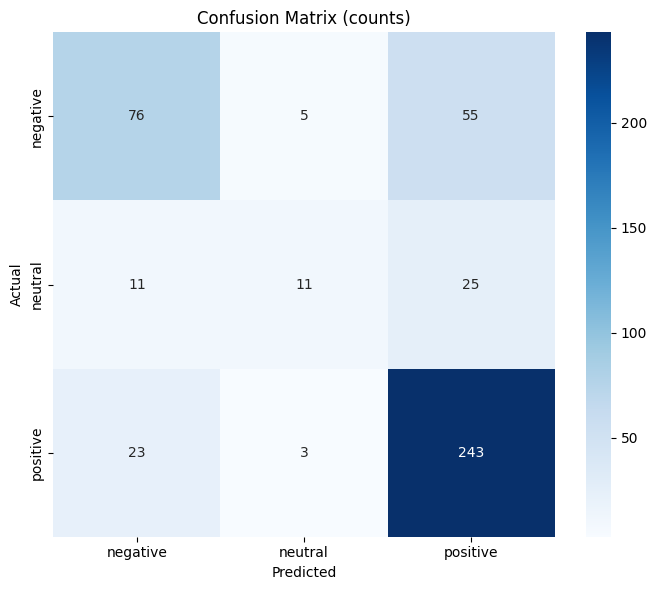

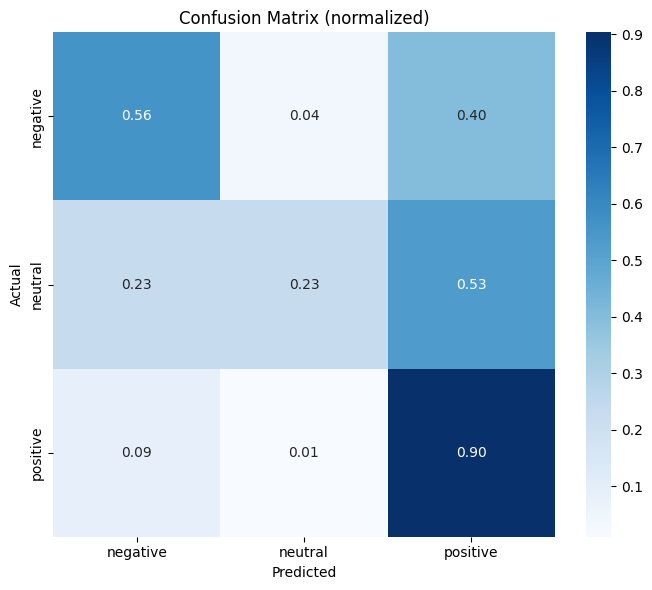

In [13]:
# ============================================================
# CONFUSION MATRIX (COUNTS & NORMALIZED)
# Computes confusion matrix and saves as PNG (counts + normalized)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure `test_preds` and `test_labels` are available from previous cell
cm = confusion_matrix(test_labels, test_preds)
cm_norm = confusion_matrix(test_labels, test_preds, normalize='true')
labels = ['negative', 'neutral', 'positive']

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (counts)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()